## 전처리

In [1]:
import pickle
with open('df_ma.pickle', 'rb') as f:
    df_ma = pickle.load(f)
print(list(df_ma.columns))

['key', 'poverty_p', 'uninsured_rate', 'plumbing_lack_rate', 'A_Score', 'A_Ratio', 'A_Density', 'V_Density', 'limited_english_rate', 'renter_rate', 'low_education_rate', 'before1970_rate', 'year_mean', 'overcrowd_all', 'overcrowd_own', 'overcrowd_rent', 'holc_num', 'Y', 'ndvi_diff', 'social', 'ndvi_holc', 'gray', 'ndvi_diff_c', 'ndvi_diff_sq', 'name']


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import spearmanr, kruskal, f_oneway
import statsmodels.formula.api as smf
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.unicode_minus'] = False

In [3]:
disease = pd.read_csv("disease2.csv")

In [4]:
disease['key'] = (
    disease['geoid']
    .astype('Int64')
    .astype(str)
    .str.zfill(11)
)

df_ma['key'] = df_ma['key'].astype(str).str.zfill(11)

di_mer = df_ma.merge(disease, on='key', how='left')

In [5]:
print(list(di_mer.columns))

['key', 'poverty_p', 'uninsured_rate', 'plumbing_lack_rate', 'A_Score', 'A_Ratio', 'A_Density', 'V_Density', 'limited_english_rate', 'renter_rate', 'low_education_rate', 'before1970_rate', 'year_mean', 'overcrowd_all', 'overcrowd_own', 'overcrowd_rent', 'holc_num', 'Y', 'ndvi_diff', 'social', 'ndvi_holc', 'gray', 'ndvi_diff_c', 'ndvi_diff_sq', 'name', 'geoid', 'TotalPopulation', '성인건강보험미가입률', '성인관절염', '폭음', '고혈압', '비피부암', '천식', '관상동맥심장질환', '건강검진(정기)', '콜레스테롤', '대장암검진률', '만성폐쇄성폐질환', '흡연률(현재)', '치과방문률', '우울증', '당뇨', '평균이하의건강', '고콜레스테롤혈증', '여가시간신체활동부족률', '정신적고통', '비만도', '신체적고통', '수면부족', '뇌졸증', '치아상실', '청각장애', '시력장애', '인지장애', '이동장애', '자기관리장애', '자립생활장애', '장애', '외로움', '푸드스탬프수령률', '식량불안정경험률', '주거불안정경험률', '공공서비스위협경험률', '교통수단부족경험률', '사회적지원부족경험률']


In [6]:
df_di = di_mer[['key', 'holc_num', 'Y','poverty_p','ndvi_diff', 'A_Density', 'limited_english_rate', 'uninsured_rate',
'성인건강보험미가입률', '성인관절염', '폭음', '고혈압', '비피부암', '천식', '관상동맥심장질환', '건강검진(정기)',
 '콜레스테롤', '대장암검진률', '만성폐쇄성폐질환', '흡연률(현재)', '치과방문률', '우울증', '당뇨', '평균이하의건강',
 '고콜레스테롤혈증', '여가시간신체활동부족률', '정신적고통', '비만도', '신체적고통', '수면부족', '뇌졸증', '치아상실',
 '청각장애', '시력장애', '인지장애', '이동장애', '자기관리장애', '자립생활장애', '장애', '외로움', '푸드스탬프수령률',
 '식량불안정경험률', '주거불안정경험률', '공공서비스위협경험률', '교통수단부족경험률', '사회적지원부족경험률']]

## 상관계수

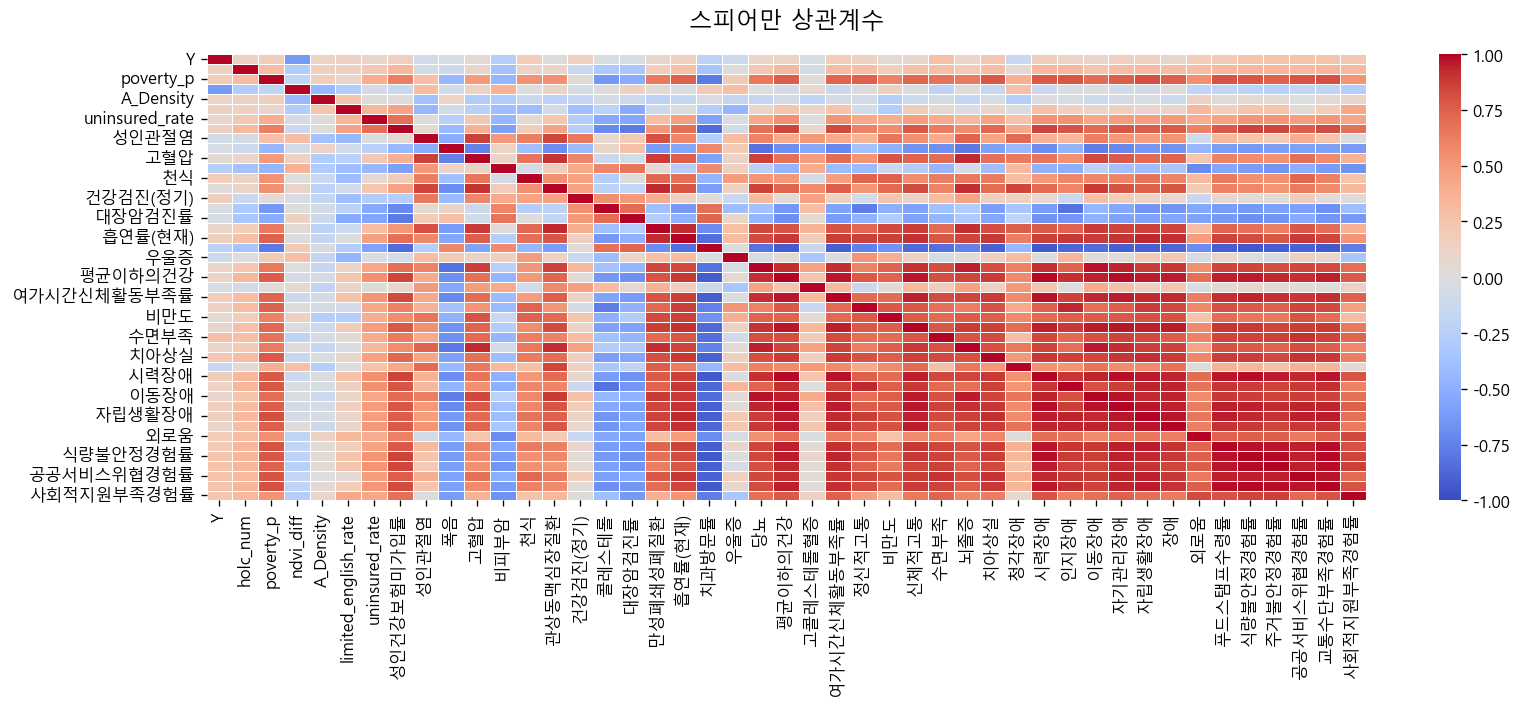

In [7]:
cols = list(df_di.columns)
cols.remove('Y')
cols.remove('key')
cols = ['Y'] + cols

spearman_table = df_di[cols].corr(method='spearman')

plt.rc('font', family='Malgun Gothic') 
plt.rcParams['axes.unicode_minus'] = False 

fig, axes = plt.subplots(figsize=(14, 6))
sns.heatmap(spearman_table, 
            cmap='coolwarm', 
            vmin=-1, vmax=1, 
            linewidths=0.5)
axes.set_title('스피어만 상관계수', fontsize=14, pad=15)

plt.tight_layout()
plt.show()

In [9]:
di_sel = df_di[['Y', 'ndvi_diff','poverty_p', 'holc_num','A_Density', 'limited_english_rate', 'uninsured_rate' , '천식','여가시간신체활동부족률', '수면부족', '식량불안정경험률', '주거불안정경험률', '우울증', '당뇨', '비만도', '고혈압', '흡연률(현재)', '정신적고통', '신체적고통', '뇌졸증', '만성폐쇄성폐질환', '관상동맥심장질환']]

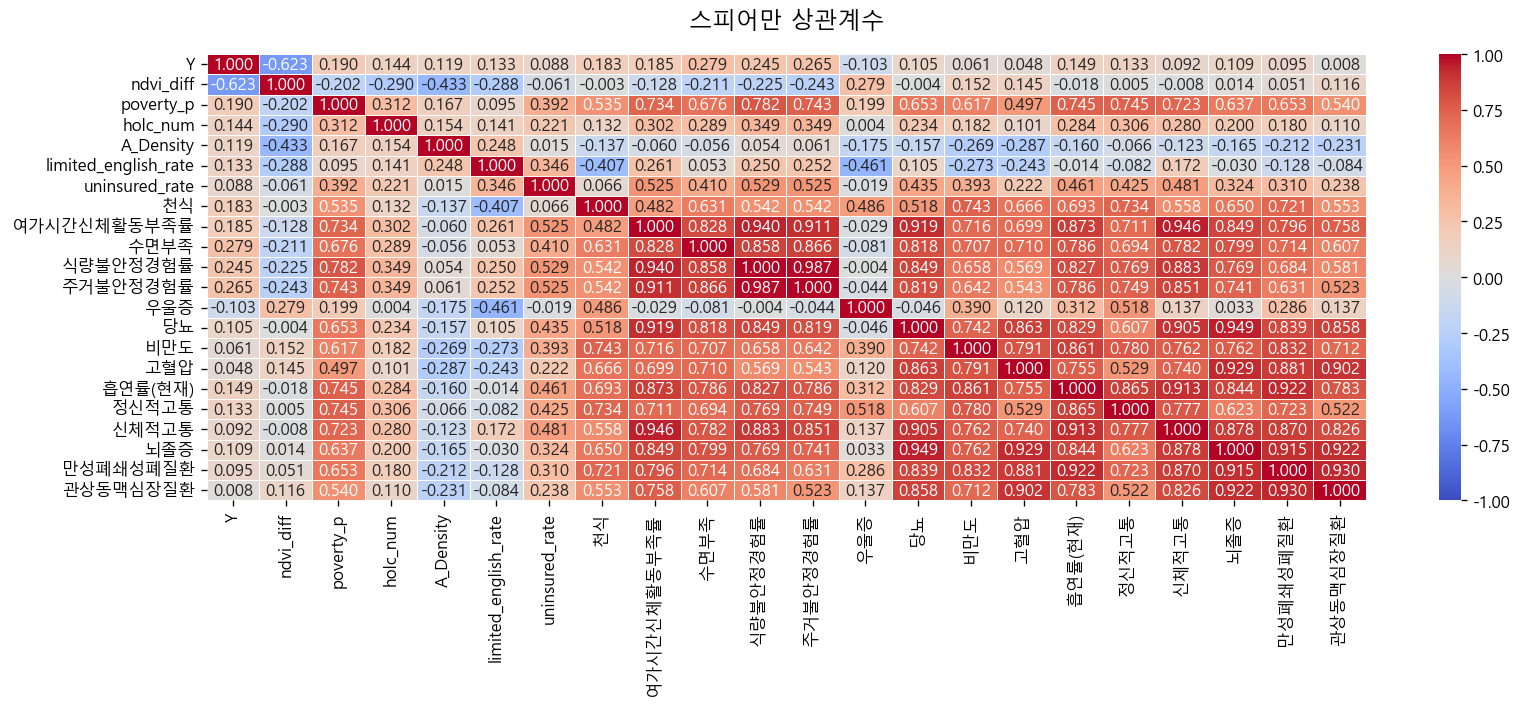

In [10]:
spearman_table = di_sel.corr(method='spearman')

plt.rc('font', family='Malgun Gothic') 
plt.rcParams['axes.unicode_minus'] = False 

fig, axes = plt.subplots(figsize=(14, 6))
sns.heatmap(spearman_table, 
            annot=True, 
            fmt=".3f", 
            cmap='coolwarm', 
            vmin=-1, vmax=1, 
            linewidths=0.5)
axes.set_title('스피어만 상관계수', fontsize=14, pad=15)

plt.tight_layout()
plt.show()

## 다중회귀분석 (OLS)

In [17]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

df_target = di_mer.copy()

X_features = ['Y', 'holc_num', 'ndvi_diff', 'A_Density', 'poverty_p','limited_english_rate', 'uninsured_rate'  ]
y_targets = ['천식','여가시간신체활동부족률', '수면부족', '식량불안정경험률', '주거불안정경험률', '우울증', '당뇨', '비만도', '고혈압', 
             '흡연률(현재)', '정신적고통', '신체적고통', '뇌졸증', '만성폐쇄성폐질환', '관상동맥심장질환']

for y_col in y_targets:
    clean_df = df_target[[y_col] + X_features].dropna()
    
    X = clean_df[X_features]
    y = clean_df[y_col]
    X_with_c = sm.add_constant(X)
    
    model = sm.OLS(y, X_with_c).fit()
    model_results = []
    for idx, feat in enumerate(X_features):
        vif_val = variance_inflation_factor(X.values, idx)
        model_results.append({
            'Feature': feat,
            'Coef': model.params[feat],
            'P-value': model.pvalues[feat],
            'VIF': vif_val
        })
        
    res_df = pd.DataFrame(model_results)
    
    print(f"\n 종속변수(Y): {y_col} | 모델 R^2: {model.rsquared:.4f}")
    print(res_df.to_string(index=False, formatters={
        'Coef': '{:.4f}'.format, 'P-value': '{:.5f}'.format, 'VIF': '{:.2f}'.format
    }))


 종속변수(Y): 천식 | 모델 R^2: 0.5698
             Feature    Coef P-value  VIF
                   Y  0.1218 0.00000 3.25
            holc_num  0.0723 0.00000 5.86
           ndvi_diff -0.0113 0.92484 4.25
           A_Density -0.2123 0.00000 3.18
           poverty_p  0.0850 0.00000 3.67
limited_english_rate -5.3875 0.00000 2.56
      uninsured_rate -0.0040 0.02449 3.25

 종속변수(Y): 여가시간신체활동부족률 | 모델 R^2: 0.6879
             Feature    Coef P-value  VIF
                   Y  0.1917 0.00000 3.25
            holc_num  0.7893 0.00000 5.86
           ndvi_diff  0.0208 0.97016 4.25
           A_Density -1.6417 0.00000 3.18
           poverty_p  0.5119 0.00000 3.67
limited_english_rate 15.9839 0.00000 2.56
      uninsured_rate  0.2605 0.00000 3.25

 종속변수(Y): 수면부족 | 모델 R^2: 0.5236
             Feature    Coef P-value  VIF
                   Y  0.2758 0.00000 3.42
            holc_num  0.6588 0.00000 5.80
           ndvi_diff -5.2642 0.00000 4.33
           A_Density -0.9678 0.00000 3.05
           pov

## 3단계 매개분석
- ndvi > LST > Health&Livelihood

In [25]:
from scipy import stats
import pandas as pd
import numpy as np
import statsmodels.api as sm

def step3_med(df, x_col, m_col, y_col):
    """
    3단계 Baron-Kenny 매개분석 (Sobel Test)
    ndvi_diff > LST > Health&Livelihood
    """
    d = df[[x_col, m_col, y_col]].dropna()
    x, m, y = d[x_col], d[m_col], d[y_col]

    m1 = sm.OLS(y, sm.add_constant(x)).fit()
    c_total = m1.params[x_col]

    m2 = sm.OLS(m, sm.add_constant(x)).fit()
    a = m2.params[x_col]

    m3 = sm.OLS(y, sm.add_constant(d[[x_col, m_col]])).fit()
    b       = m3.params[m_col]
    c_prime = m3.params[x_col]

    indirect = a * b
    sobel_se = np.sqrt(b**2 * m2.bse[x_col]**2 + a**2 * m3.bse[m_col]**2)
    z        = indirect / sobel_se
    p_sobel  = 2 * (1 - stats.norm.cdf(abs(z)))
    ratio    = indirect / c_total * 100 if c_total != 0 else np.nan

    if p_sobel < 0.05 and abs(c_prime) < abs(c_total):
        med_type = '완전매개' if m3.pvalues[x_col] > 0.05 else '부분매개'
    elif p_sobel >= 0.05:
        med_type = '매개없음'
    else:
        med_type = '억제효과'

    return {
        'outcome': y_col, 'n': len(d),
        'c_total': round(c_total, 4), 'c_total_p': round(m1.pvalues[x_col], 4),
        'a(ndvi>LST)': round(a, 4), 'a_p': round(m2.pvalues[x_col], 4),
        'b(LST>disease)': round(b, 4), 'b_p': round(m3.pvalues[m_col], 4),
        'c_prime': round(c_prime, 4), 'c_prime_p': round(m3.pvalues[x_col], 4),
        'indirect': round(indirect, 4),
        'sobel_z': round(z, 4), 'sobel_p': round(p_sobel, 4),
        'ratio(%)': round(ratio, 2), 'med_type': med_type
    }

In [37]:
cols_3step = ['outcome', 'n', 'c_total', 'c_total_p',
              'a(ndvi→LST)', 'a_p',
              'b(LST→disease)', 'b_p',
              'c_prime', 'c_prime_p',
              'indirect', 'sobel_z', 'sobel_p', 'ratio(%)', 'med_type']

df_3step[cols_3step].style.set_table_styles([
    {'selector': 'th, td', 'props': [('white-space', 'nowrap'), ('text-align', 'center')]}
]).format({
    'c_total':         '{:.4f}',
    'c_total_p':       '{:.4f}',
    'a(ndvi→LST)':     '{:.4f}',
    'a_p':             '{:.4f}',
    'b(LST→disease)':  '{:.4f}',
    'b_p':             '{:.4f}',
    'c_prime':         '{:.4f}',
    'c_prime_p':       '{:.4f}',
    'indirect':        '{:.4f}',
    'sobel_z':         '{:.4f}',
    'sobel_p':         '{:.4f}',
    'ratio(%)':        '{:.2f}',
})

,outcome,n,c_total,c_total_p,a(ndvi→LST),a_p,b(LST→disease),b_p,c_prime,c_prime_p,indirect,sobel_z,sobel_p,ratio(%),med_type
0,천식,11731,0.5305,0.0000,-9.1064,0.0000,0.2344,0.0000,2.6655,0.0000,-2.1350,-26.1442,0.0000,-402.44,억제효과
1,여가시간신체활동부족률,11731,-6.5793,0.0000,-9.1064,0.0000,0.8645,0.0000,1.2934,0.0975,-7.8727,-18.1168,0.0000,119.66,완전매개
2,수면부족,12658,-7.8090,0.0000,-9.5957,0.0000,0.7152,0.0000,-0.9466,0.0440,-6.8624,-24.7200,0.0000,87.88,부분매개
3,식량불안정경험률,10548,-16.4965,0.0000,-9.0634,0.0000,1.1612,0.0000,-5.9720,0.0000,-10.5244,-17.4179,0.0000,63.80,부분매개
4,주거불안정경험률,10548,-13.4996,0.0000,-9.0634,0.0000,0.8897,0.0000,-5.4357,0.0000,-8.0640,-18.6088,0.0000,59.73,부분매개
5,우울증,11731,10.1876,0.0000,-9.1064,0.0000,0.2339,0.0000,12.3179,0.0000,-2.1302,-11.2756,0.0000,-20.91,억제효과
6,당뇨,11731,2.2122,0.0000,-9.1064,0.0000,0.4049,0.0000,5.8993,0.0000,-3.6872,-16.4676,0.0000,-166.68,억제효과
7,비만도,11731,13.6775,0.0000,-9.1064,0.0000,1.0661,0.0000,23.3859,0.0000,-9.7084,-24.0690,0.0000,-70.98,억제효과
8,고혈압,11731,12.0386,0.0000,-9.1064,0.0000,0.8152,0.0000,19.4623,0.0000,-7.4237,-19.8694,0.0000,-61.67,억제효과
9,흡연률(현재),11731,1.7903,0.0000,-9.1064,0.0000,0.6181,0.0000,7.4188,0.0000,-5.6285,-20.9966,0.0000,-314.39,억제효과


## 4단계 직렬 매개분석
- X = holc_num, M1 = ndvi_diff, M2 = Y(LST), 결과 = 질병변수

In [31]:
def step4_med(data, outcome, n_boot=1000, seed=1):
    """
    X=holc_num, M1=ndvi_diff, M2=Y(LST), 결과=outcome
    Baron-Kenny 확장 4단계 + Bootstrap CI
    """
    d = data[['holc_num', 'ndvi_diff', 'Y', outcome]].dropna().copy()
    if len(d) < 100:
        return None

    x, m1, m2 = 'holc_num', 'ndvi_diff', 'Y'

    # 1: X > 질병 (총효과)
    s1 = sm.OLS(d[outcome],
                sm.add_constant(d[[x]])).fit()
    c_total   = s1.params[x]
    c_total_p = s1.pvalues[x]

    # 2a: X > M1
    s2a = sm.OLS(d[m1],
                 sm.add_constant(d[[x]])).fit()
    a1   = s2a.params[x]

    # 2b: X + M1 > M2
    s2b = sm.OLS(d[m2],
                 sm.add_constant(d[[x, m1]])).fit()
    a2   = s2b.params[x]
    d21  = s2b.params[m1]

    # 3: X + M1 + M2 > 질병 (직접효과)
    s3 = sm.OLS(d[outcome],
                sm.add_constant(d[[x, m1, m2]])).fit()
    b1        = s3.params[m1]
    b2        = s3.params[m2]
    c_prime   = s3.params[x]
    c_prime_p = s3.pvalues[x]
    b1_p      = s3.pvalues[m1]
    b2_p      = s3.pvalues[m2]

    # 경로 분해
    ind1       = a1 * b1 
    ind2       = a2 * b2
    ind_serial = a1 * d21 * b2 
    ind_total  = ind1 + ind2 + ind_serial

    # Bootstrap
    np.random.seed(seed)
    boot = []
    for _ in range(n_boot):
        s = d.sample(frac=1, replace=True)
        try:
            _a1  = sm.OLS(s[m1],
                          sm.add_constant(s[[x]])).fit().params[x]
            _s2b = sm.OLS(s[m2],
                          sm.add_constant(s[[x, m1]])).fit()
            _a2, _d21 = _s2b.params[x], _s2b.params[m1]
            _s3  = sm.OLS(s[outcome],
                          sm.add_constant(s[[x, m1, m2]])).fit()
            _b1, _b2  = _s3.params[m1], _s3.params[m2]
            boot.append(_a1*_b1 + _a2*_b2 + _a1*_d21*_b2)
        except:
            continue
    ci = np.percentile(boot, [2.5, 97.5])
    sig = '유의' if ci[0] * ci[1] > 0 else '비유의'

    if ci[0] * ci[1] > 0:
        if (ind_total / c_total) < 0:
            med_type = '억제효과'
        elif c_prime_p > 0.05:
            med_type = '완전매개'
        else:
            med_type = '부분매개'
    else:
        med_type = '매개없음'

    return {
        'outcome':      outcome,
        'n':            len(d),
        'c_total':      c_total,   'c_total_p':   c_total_p,
        'a1(X>M1)':    a1,
        'd21(M1>M2)':  d21,
        'a2(X>M2)':    a2,
        'b1(M1>Y)':    b1,        'b1_p':        b1_p,
        'b2(M2>Y)':    b2,        'b2_p':        b2_p,
        'c_prime':      c_prime,   'c_prime_p':   c_prime_p,
        'ind1 M1>질병':  ind1,
        'ind2 M2>질병':  ind2,
        'ind3 직렬':     ind_serial,
        'ind_total':    ind_total,
        'boot_CI_lo':   ci[0],     'boot_CI_hi':  ci[1],
        'CI_sig':       sig,
        'ratio':        ind_total / c_total * 100 if c_total != 0 else np.nan,
        'med_type':     med_type,
    }

outcome_vars = [
    '천식', '여가시간신체활동부족률', '수면부족',
    '식량불안정경험률', '주거불안정경험률',
    '우울증', '당뇨', '비만도', '고혈압',
    '흡연률(현재)', '정신적고통', '신체적고통',
    '뇌졸증', '만성폐쇄성폐질환', '관상동맥심장질환',
]

results_serial = []
for var in outcome_vars:
    if var not in df_di.columns:
        print(f"{var} 컬럼 없음")
        continue
    r = step4_med(df_di, var)
    if r is not None:
        results_serial.append(r)

In [35]:
df_step4 = pd.DataFrame(results_serial)
cols = ['outcome', 'n', 'c_total', 'c_total_p', 'ind1 M1>질병', 'ind2 M2>질병', 'ind3 직렬', 
        'ind_total', 'boot_CI_lo', 'boot_CI_hi', 'CI_sig', 'ratio', 'med_type']

df_step4[cols].style.set_table_styles([
    {'selector': 'th, td', 'props': [('white-space', 'nowrap'), ('text-align', 'center')]}
]).format({
    'c_total': '{:.4f}',
    'c_total_p': '{:.4f}',
    'ind1 M1>질병': '{:.4f}',
    'ind2 M2>질병': '{:.4f}',
    'ind3 직렬': '{:.4f}',
    'ind_total': '{:.4f}',
    'boot_CI_lo': '{:.4f}',
    'boot_CI_hi': '{:.4f}',
    'ratio': '{:.2f}',
})

,outcome,n,c_total,c_total_p,ind1 M1>질병,ind2 M2>질병,ind3 직렬,ind_total,boot_CI_lo,boot_CI_hi,CI_sig,ratio,med_type
0,천식,11731,0.3072,0.0000,-0.1583,0.0044,0.1018,-0.0521,-0.0693,-0.0367,유의,-16.96,억제효과
1,여가시간신체활동부족률,11731,3.7388,0.0000,-0.3745,0.0160,0.3721,0.0135,-0.0614,0.0868,비유의,0.36,매개없음
2,수면부족,12658,2.2599,0.0000,-0.1399,-0.0131,0.3355,0.1826,0.1358,0.2294,유의,8.08,부분매개
3,식량불안정경험률,10548,5.7483,0.0000,-0.1840,-0.0419,0.5411,0.3152,0.2168,0.4217,유의,5.48,부분매개
4,주거불안정경험률,10548,4.1277,0.0000,-0.0672,-0.0320,0.4137,0.3145,0.2411,0.3955,유의,7.62,부분매개
5,우울증,11731,0.0313,0.5380,-0.6396,0.0044,0.1013,-0.5339,-0.5756,-0.4935,유의,-1704.08,억제효과
6,당뇨,11731,1.4066,0.0000,-0.4217,0.0075,0.1744,-0.2398,-0.2803,-0.2035,유의,-17.05,억제효과
7,비만도,11731,2.0955,0.0000,-1.3750,0.0199,0.4610,-0.8941,-0.9904,-0.8030,유의,-42.67,억제효과
8,고혈압,11731,1.0592,0.0000,-1.0845,0.0152,0.3532,-0.7161,-0.7972,-0.6406,유의,-67.61,억제효과
9,흡연률(현재),11731,2.0753,0.0000,-0.5538,0.0115,0.2664,-0.2759,-0.3264,-0.2318,유의,-13.30,억제효과
